# Customer Segmentation Analysis using K-Means Clustering

## Project Overview

Customer segmentation is the process of dividing customers into distinct groups based on their purchasing behaviour. This enables businesses to understand customer needs, improve marketing strategies, and increase customer satisfaction.

In this project, the Online Retail dataset is analysed using **Recency, Frequency, and Monetary (RFM)** analysis. These features are standardized and used to build a **K-Means Clustering** model that segments customers into meaningful groups for business decision-making.

### Objectives

- Load and preprocess customer transaction data.
- Perform data cleaning and exploratory data analysis.
- Create RFM (Recency, Frequency, Monetary) features.
- Standardize the data using StandardScaler.
- Apply the K-Means clustering algorithm.
- Determine the optimal number of clusters using the Elbow Method.
- Visualize customer clusters.
- Profile each customer segment.
- Provide business recommendations for each customer group.

# Import Required Libraries

The following libraries are used for data manipulation, visualization, feature scaling, and customer segmentation using K-Means clustering.

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


# Load Dataset

The Online Retail dataset is loaded into a Pandas DataFrame to begin the analysis.

In [3]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("online_retail.csv", encoding='ISO-8859-1')

print("✅ Dataset Loaded Successfully!")

df.head()

✅ Dataset Loaded Successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Dataset Overview

Before performing customer segmentation, it is important to understand the structure of the dataset, including the number of rows, columns, data types, and sample records.

In [4]:
# Shape of Dataset

print("="*50)
print("DATASET SHAPE")
print("="*50)

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")



DATASET SHAPE
Number of Rows    : 541909
Number of Columns : 8


In [5]:
# Display Column Names

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [7]:
# First Five Records

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
# Descriptive Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


# Data Cleaning

Data cleaning is an essential preprocessing step that improves the quality of the dataset by removing missing values, duplicate records, cancelled transactions, and invalid entries.

In [9]:
# Check Missing Values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Check Duplicate Records

print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 5268


In [11]:
# Remove rows where CustomerID is missing

df = df.dropna(subset=['CustomerID'])

print("Remaining Rows :", len(df))

Remaining Rows : 406829


In [12]:
# Remove cancelled transactions

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Remaining Rows :", len(df))

Remaining Rows : 397924


In [13]:
# Keep only positive Quantity and Unit Price

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Remaining Rows :", len(df))

Remaining Rows : 397884


# RFM Feature Engineering

RFM (Recency, Frequency, Monetary) analysis is a customer segmentation technique that evaluates customer purchasing behavior based on:

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Number of purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These features are widely used in customer analytics and marketing to identify valuable customer segments.

In [14]:
# Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[us]


In [16]:
# Create reference date

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [19]:
# Create TotalPrice

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
# Calculate RFM

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# RFM Summary Statistics

The summary statistics provide an overview of customer purchasing behavior based on Recency, Frequency, and Monetary values.

In [21]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


In [22]:
# Standardize RFM Features

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("Shape:", rfm_scaled.shape)

Shape: (4338, 3)


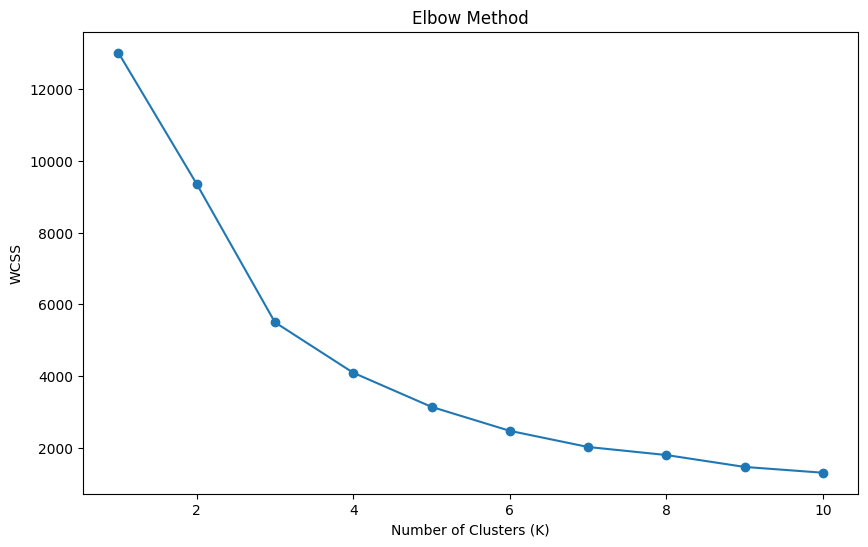

In [23]:
# Elbow Method

wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

In [24]:
from sklearn.cluster import KMeans

# Apply KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [25]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

In [26]:
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.983906,4.852677,2012.111620
1,246.023788,1.582800,631.141410
2,7.142857,80.214286,122888.407143


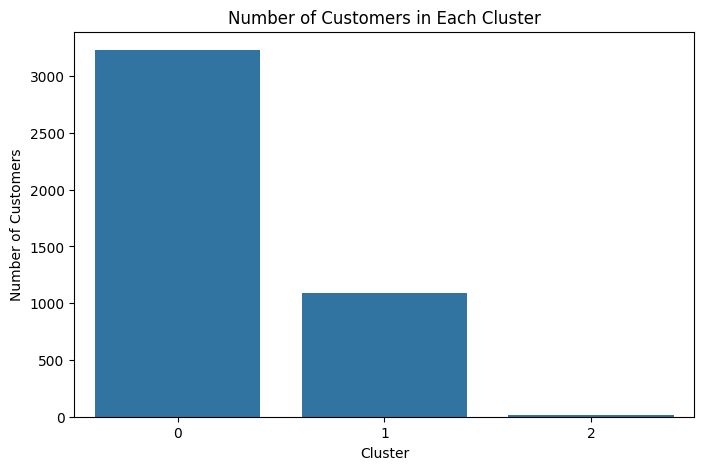

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='Cluster', data=rfm)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

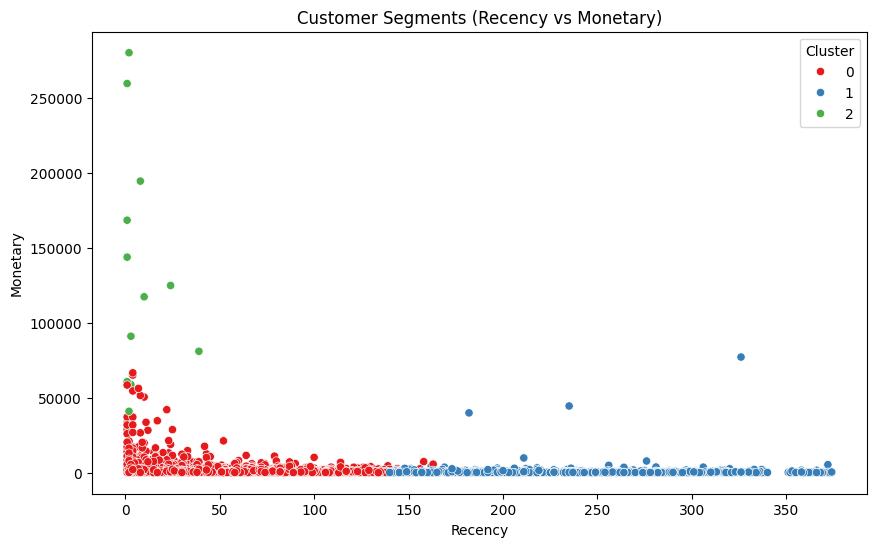

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segments (Recency vs Monetary)")

plt.show()

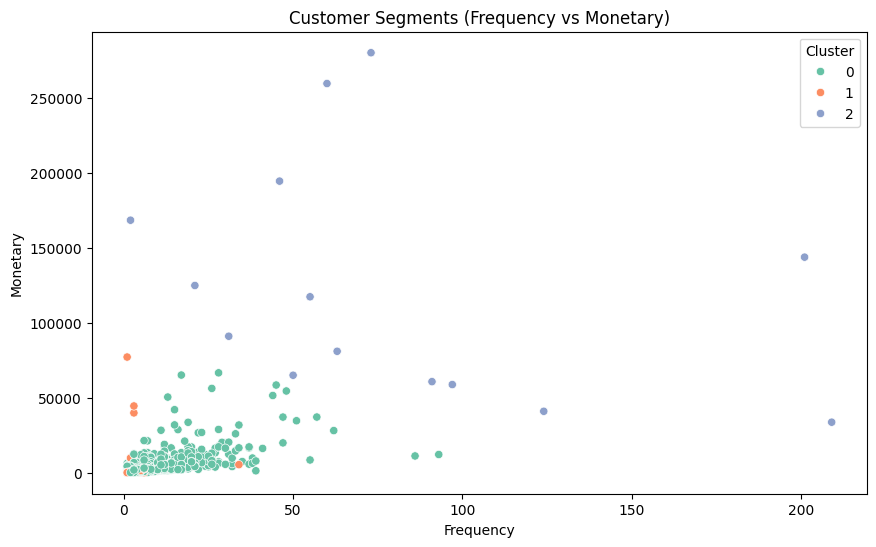

In [29]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments (Frequency vs Monetary)")

plt.show()

# Marketing Insights

### Cluster 0
- Customers purchase frequently and spend a high amount.
- These are loyal and valuable customers.
- **Recommendation:** Offer loyalty rewards, exclusive discounts, and premium membership benefits.

### Cluster 1
- Customers have moderate purchase frequency and spending.
- These customers have growth potential.
- **Recommendation:** Provide personalized offers and cross-selling recommendations.

### Cluster 2
- Customers purchase infrequently and spend less.
- These customers are at risk of becoming inactive.
- **Recommendation:** Launch re-engagement campaigns, discount coupons, and reminder emails.